# Lecture 3 — Pandas, APIs & Econometrics
### Python for Economists · University of Bologna · 2025/2026

---

## What we cover today

0. **Warm-up**: what `pandas` + an API can do in 30 seconds
1. Why pandas? From dicts to DataFrames
2. Selection, filtering, groupby, merge, reshape
3. Fetching real data from public APIs
4. **OLS regression with `statsmodels`**
5. **Panel data with fixed effects using `linearmodels`**
6. **Exercise** + **Milestone**: identify your research dataset

---

> **Installation** (in your course environment):
>
> ```bash
> conda activate <your_env>
> conda install -c conda-forge wbdata
> pip install linearmodels
> ```
>
> `requests` ships with Anaconda — nothing to install for §6.1.

In [40]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

print(f"pandas      {pd.__version__}")
print(f"statsmodels {sm.__version__}")

# pip install linearmodels
try:
    from linearmodels.panel import PanelOLS, PooledOLS, RandomEffects
    import linearmodels
    print(f"linearmodels {linearmodels.__version__}")
except ImportError:
    print("linearmodels not installed — run: pip install linearmodels")

pandas      3.0.2
statsmodels 0.14.6
linearmodels 7.0


---
## 0. Warm-up — from API to chart in 30 seconds

Before we look at a single DataFrame method, let's see what we can do with the tools of today. I'll pull *live* inflation data for five eurozone countries — straight from the World Bank — and plot twenty years of price dynamics.

Watch closely. By the end of the lecture you will be able to write this yourself.

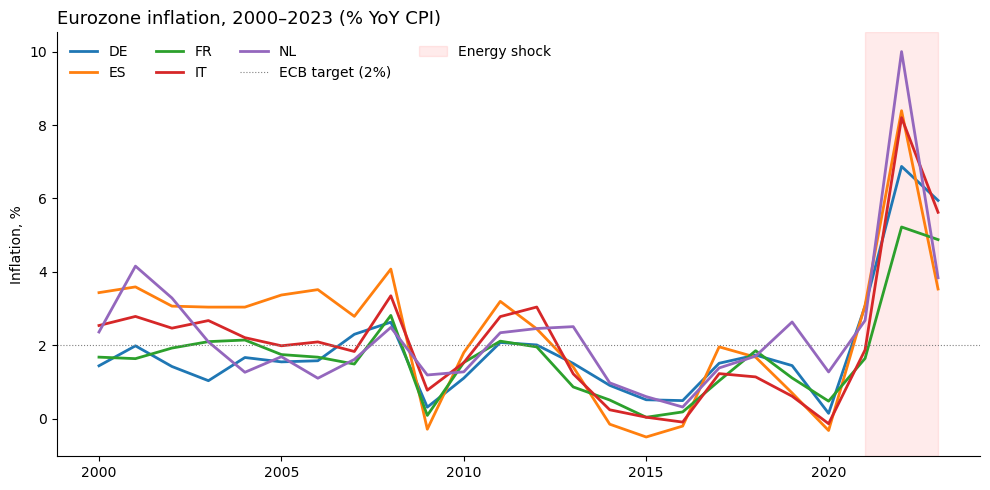

In [41]:
# Warm-up demo: live inflation data from the World Bank + annotated plot
import matplotlib.pyplot as plt
import pandas as pd

# Eurozone subset — ISO2 codes; the full English names come back from wbdata
countries = {"IT": "Italy", "DE": "Germany", "FR": "France",
             "ES": "Spain", "NL": "Netherlands"}

try:
    import wbdata
    infl = wbdata.get_dataframe(
        {"FP.CPI.TOTL.ZG": "inflation"},
        country=list(countries.keys()),
        date=("2000", "2023"),
    ).reset_index()
    # wbdata returns the country's full name — map back to the ISO2 code
    name_to_code = {v: k for k, v in countries.items()}
    infl["country"] = infl["country"].map(name_to_code)
    infl["year"] = infl["date"].astype(int)
    wide = infl.pivot(index="year", columns="country", values="inflation").sort_index()
except Exception as e:
    # Fallback to cached illustrative values if the API is unreachable in class
    msg = f"{type(e).__name__}: {e}"
    if isinstance(e, ModuleNotFoundError):
        msg += f"  [modulo mancante: {e.name}]"
    print(f"World Bank fetch failed ({msg}), using cached values.")
    years = list(range(2000, 2024))
    cached = {
        "IT": [2.6,2.3,2.6,2.8,2.3,2.2,2.2,2.0,3.5,0.8,1.5,2.7,3.0,1.2,0.2,0.0,-0.1,1.2,1.1,0.6,-0.1,1.9,8.2,5.6],
        "DE": [1.4,2.0,1.4,1.0,1.7,1.5,1.6,2.3,2.6,0.3,1.1,2.1,2.0,1.5,0.9,0.5,0.5,1.5,1.7,1.4,0.4,3.1,6.9,5.9],
        "FR": [1.7,1.6,1.9,2.1,2.1,1.7,1.7,1.5,2.8,0.1,1.5,2.1,2.0,0.9,0.5,0.0,0.2,1.0,1.9,1.1,0.5,1.6,5.2,4.9],
        "ES": [3.4,3.6,3.1,3.0,3.0,3.4,3.5,2.8,4.1,-0.3,1.8,3.2,2.4,1.4,-0.2,-0.5,-0.2,2.0,1.7,0.7,-0.3,3.1,8.4,3.5],
        "NL": [2.3,5.1,3.9,2.2,1.4,1.7,1.2,1.6,2.2,1.0,0.9,2.5,2.8,2.6,0.3,0.2,0.1,1.3,1.6,2.6,1.3,2.8,11.6,4.1],
    }
    wide = pd.DataFrame(cached, index=years)

fig, ax = plt.subplots(figsize=(10, 5))
wide.plot(ax=ax, linewidth=2)
ax.axhline(2, color="grey", linestyle=":", linewidth=0.8, label="ECB target (2%)")
ax.axvspan(2021, 2023, color="red", alpha=0.08, label="Energy shock")
ax.set_title("Eurozone inflation, 2000–2023 (% YoY CPI)", fontsize=13, loc="left")
ax.set_xlabel("")
ax.set_ylabel("Inflation, %")
ax.legend(loc="upper left", frameon=False, ncol=4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

**What just happened?**

Four lines of conceptual content:
1. An **API call** retrieved data directly from the World Bank — no manual download, no CSV to clean.
2. `pandas` reshaped the data from long to wide format.
3. `matplotlib` drew the figure, with a target line and a highlighted shock region.
4. All in under 20 lines of code.

The 2022 inflation spike is clearly visible — and so is the fact that the ECB's 2% target has held for most of the sample. By the end of today's lecture, you'll have built every step of this pipeline yourself.

**Discussion prompts:**
- Which country looks most vulnerable to the 2022 shock? Which most stable?
- Why did Spain and Italy have negative inflation in 2014–2016?

**Answers:**
- Spain and Italy had negative inflation in 2014–2016: sovereign debt crisis aftermath and ECB deflation concerns.

**Why this matters:** primes the motivation for `pandas` + API access as *research* tools, not just programming toys.

---
## 1–5. Pandas essentials

We cover the core pandas operations quickly — building on L2 where we worked with dicts and lists manually.

In [42]:
# From a dict of lists
df = pd.DataFrame({
    "country":   ["Italy","Germany","France","Spain","Netherlands"],
    "code":      ["ITA","DEU","FRA","ESP","NLD"],
    "gdp":       [2010.0,4082.0,2794.0,1419.0,1118.0],
    "growth":    [0.73,-0.30,0.90,2.50,0.10],
    "inflation": [5.8,6.1,5.7,3.5,3.8],
})
df = df.set_index("code")
df["real_growth"] = df["growth"] - df["inflation"]
print(df.shape)
df.describe().round(2)

(5, 5)


,gdp,growth,inflation,real_growth
count,5.00,5.00,5.00,5.00
mean,2284.60,0.79,4.98,-4.19
std,1191.19,1.07,1.23,2.03
min,1118.00,-0.30,3.50,-6.40
25%,1419.00,0.10,3.80,-5.07
50%,2010.00,0.73,5.70,-4.80
75%,2794.00,0.90,5.80,-3.70
max,4082.00,2.50,6.10,-1.00


In [43]:
# Boolean filtering
print(df[(df["growth"] > 0) & (df["inflation"] < 5)])

# .query() syntax
print(df.query("growth > 0 and inflation < 5"))

          country     gdp  growth  inflation  real_growth
code                                                     
ESP         Spain  1419.0     2.5        3.5         -1.0
NLD   Netherlands  1118.0     0.1        3.8         -3.7
          country     gdp  growth  inflation  real_growth
code                                                     
ESP         Spain  1419.0     2.5        3.5         -1.0
NLD   Netherlands  1118.0     0.1        3.8         -3.7


In [44]:
panel = pd.DataFrame({
    "country":    ["Italy","Italy","Italy","Germany","Germany","Germany",
                   "Spain","Spain","Spain"],
    "year":       [2021,2022,2023,2021,2022,2023,2021,2022,2023],
    "gdp_growth": [6.58,7.31,5.29,2.88,7.47,5.49,5.55,10.02,6.85],
    "inflation":  [1.9,8.7,5.8,3.2,8.7,6.1,3.1,8.4,3.5],
    "unemployment":[9.5,8.1,6.7,3.7,3.0,2.9,14.8,12.9,11.8],
})

panel.groupby("country").agg(
    avg_growth   =("gdp_growth",   "mean"),
    avg_inflation=("inflation",    "mean"),
    avg_unemp    =("unemployment", "mean"),
).round(2)

,avg_growth,avg_inflation,avg_unemp
country,,,
Germany,5.28,6.00,3.20
Italy,6.39,5.47,8.10
Spain,7.47,5.00,13.17


---
## 6. Fetching real data from public APIs

Everything we've done so far used toy DataFrames. In research you usually start from an **API** — a URL you query that returns structured data.

We'll use the **World Bank** API (free, no key required, data for 200+ countries) and do the same fetch **twice**:

- **§6.1** — by hand, with `requests`. This shows what an API actually *is*: a URL, some query parameters, a JSON response you parse. Every REST API you'll meet works this way.
- **§6.2** — with `wbdata`, a Python wrapper. Once you've seen what happens underneath, the one-liner version is a legitimate shortcut.

The point of doing both: **wrappers exist only for the most popular data sources**. The next API you need (a central bank, a ministry, a private provider) probably won't have one — and then `requests` is all you have.

### 6.1 — Talking to the API by hand with `requests`

The World Bank exposes its data at URLs of the form:

```
https://api.worldbank.org/v2/country/{codes}/indicator/{indicator_code}?format=json&date=YYYY:YYYY
```

Let's construct one, send a GET request, and look at what comes back.

In [45]:
import requests

countries = ["IT","DE","FR","ES","NL","PT","GR","BE","AT","FI"]
indicator = "NY.GDP.MKTP.KD.ZG"   # real GDP growth, annual %

url = f"https://api.worldbank.org/v2/country/{';'.join(countries)}/indicator/{indicator}"
params = {"format": "json", "date": "2000:2023", "per_page": 1000}

resp = requests.get(url, params=params, timeout=30)
resp.raise_for_status()           # raise an error if the HTTP status is not 2xx

payload = resp.json()

# The World Bank returns a two-element JSON array:
#   payload[0] = pagination metadata (page, pages, per_page, total, ...)
#   payload[1] = list of observations, one per (country, year)
print("Full request URL:", resp.url)
print("Metadata        :", payload[0])
print("\nFirst raw observation:")
print(payload[1][0])

Full request URL: https://api.worldbank.org/v2/country/IT;DE;FR;ES;NL;PT;GR;BE;AT;FI/indicator/NY.GDP.MKTP.KD.ZG?format=json&date=2000%3A2023&per_page=1000
Metadata        : {'page': 1, 'pages': 1, 'per_page': 1000, 'total': 240, 'sourceid': '2', 'lastupdated': '2026-04-08'}

First raw observation:
{'indicator': {'id': 'NY.GDP.MKTP.KD.ZG', 'value': 'GDP growth (annual %)'}, 'country': {'id': 'AT', 'value': 'Austria'}, 'countryiso3code': 'AUT', 'date': '2023', 'value': -0.786244288594673, 'unit': '', 'obs_status': '', 'decimal': 1}


In [46]:
# Build a clean DataFrame from the raw JSON observations.
# Each observation is a dict with keys: country, countryiso3code, date, value, ...
g = pd.DataFrame([
    {"country":    obs["country"]["id"],   # ISO2 code
     "year":       int(obs["date"]),
     "gdp_growth": obs["value"]}
    for obs in payload[1]
    if obs["value"] is not None           # drop years with no reported value
])

print(g.shape)
g.head()

(240, 3)


,country,year,gdp_growth
0,AT,2023,-0.786244
1,AT,2022,5.330964
2,AT,2021,4.923092
3,AT,2020,-6.318255
4,AT,2019,1.754976


### 6.2 — The same thing with a wrapper: `wbdata`

Now that you've seen what the HTTP/JSON layer looks like, we can accept a library that hides it. `wbdata` is the actively-maintained Python wrapper for the World Bank. Bonus: it can fetch **multiple indicators at once** and hand you back a ready-to-use DataFrame.

In [47]:
import wbdata

countries = ["IT","DE","FR","ES","NL","PT","GR","BE","AT","FI"]

# A dict mapping World Bank indicator codes to the column names we want
indicators = {
    "NY.GDP.MKTP.KD.ZG": "gdp_growth",
    "SL.UEM.TOTL.ZS":    "unemployment",
}

df = wbdata.get_dataframe(
    indicators,
    country=countries,
    date=("2000", "2023"),
).reset_index()

# wbdata returns full country names ("Italy", "Germany", ...) — map back to ISO2
# so the country column matches what we saw in §6.1 and stays compact downstream.
name_to_code = {
    "Italy":"IT","Germany":"DE","France":"FR","Spain":"ES","Netherlands":"NL",
    "Portugal":"PT","Greece":"GR","Belgium":"BE","Austria":"AT","Finland":"FI",
}
df["country"] = df["country"].map(name_to_code)
df = df.rename(columns={"date": "year"})
df["year"] = df["year"].astype(int)
df = df.dropna().reset_index(drop=True)

df.to_csv("eurozone_panel.csv", index=False)
print(df.shape)
df.head()

(240, 4)


,country,year,gdp_growth,unemployment
0,AT,2023,-0.786244,5.264
1,AT,2022,5.330964,4.992
2,AT,2021,4.923092,6.459
3,AT,2020,-6.318255,5.201
4,AT,2019,1.754976,4.560


### World Bank indicators — mini dictionary

A curated set of the indicator codes most commonly used in applied macro / political-economy work. Pass any of these as the *key* in `wbdata.get_dataframe({code: name}, ...)`, or substitute the `indicator` variable in the raw-`requests` version of §6.1.

Full catalogue: <https://data.worldbank.org/indicator> — or use `wbdata.search_indicators("keyword")` from the notebook.

**Growth & Output**

| Code | Indicator | Units |
|---|---|---|
| `NY.GDP.MKTP.KD.ZG` | GDP growth, real | annual % |
| `NY.GDP.MKTP.CD` | GDP, nominal | current USD |
| `NY.GDP.MKTP.KD` | GDP, real | constant 2015 USD |
| `NY.GDP.PCAP.KD` | GDP per capita, real | constant 2015 USD |
| `NY.GDP.PCAP.KD.ZG` | GDP per capita growth | annual % |
| `NY.GDP.PCAP.PP.KD` | GDP per capita, PPP | constant 2017 international $ |

**Labour market**

| Code | Indicator | Units |
|---|---|---|
| `SL.UEM.TOTL.ZS` | Unemployment rate, total | % of labour force |
| `SL.UEM.1524.ZS` | Youth unemployment (15–24) | % of youth labour force |
| `SL.TLF.CACT.ZS` | Labour force participation | % of population 15+ |
| `SL.TLF.CACT.FE.ZS` | Female labour force participation | % of female pop. 15+ |
| `SL.EMP.TOTL.SP.ZS` | Employment-to-population ratio | % of pop. 15+ |

**Prices & exchange rates**

| Code | Indicator | Units |
|---|---|---|
| `FP.CPI.TOTL.ZG` | CPI inflation | annual % |
| `FP.CPI.TOTL` | Consumer price index | 2010 = 100 |
| `NY.GDP.DEFL.KD.ZG` | GDP deflator, inflation | annual % |
| `PA.NUS.FCRF` | Official exchange rate | LCU per USD, period avg |

**Fiscal & public finance**

| Code | Indicator | Units |
|---|---|---|
| `GC.DOD.TOTL.GD.ZS` | Central government debt | % of GDP |
| `GC.XPN.TOTL.GD.ZS` | General government expenditure | % of GDP |
| `GC.REV.XGRT.GD.ZS` | General government revenue (ex. grants) | % of GDP |
| `GC.BAL.CASH.GD.ZS` | Cash surplus / deficit | % of GDP |
| `GC.TAX.TOTL.GD.ZS` | Tax revenue | % of GDP |

**Trade & external sector**

| Code | Indicator | Units |
|---|---|---|
| `NE.EXP.GNFS.ZS` | Exports of goods and services | % of GDP |
| `NE.IMP.GNFS.ZS` | Imports of goods and services | % of GDP |
| `BN.CAB.XOKA.GD.ZS` | Current account balance | % of GDP |
| `BX.KLT.DINV.WD.GD.ZS` | FDI, net inflows | % of GDP |

**Money & finance**

| Code | Indicator | Units |
|---|---|---|
| `FM.LBL.BMNY.GD.ZS` | Broad money (M2) | % of GDP |
| `FR.INR.RINR` | Real interest rate | % |
| `FS.AST.DOMS.GD.ZS` | Domestic credit provided by financial sector | % of GDP |

**Demography & human capital**

| Code | Indicator | Units |
|---|---|---|
| `SP.POP.TOTL` | Population, total | persons |
| `SP.POP.GROW` | Population growth | annual % |
| `SP.DYN.LE00.IN` | Life expectancy at birth | years |
| `SP.URB.TOTL.IN.ZS` | Urban population | % of total |
| `SE.ADT.LITR.ZS` | Adult literacy rate | % of pop. 15+ |
| `SE.XPD.TOTL.GD.ZS` | Government expenditure on education | % of GDP |

**Inequality & poverty**

| Code | Indicator | Units |
|---|---|---|
| `SI.POV.GINI` | Gini index | 0–100 |
| `SI.POV.DDAY` | Poverty headcount at \$2.15/day (2017 PPP) | % of pop. |
| `SI.DST.10TH.10` | Income share held by highest 10% | % |

**Governance & institutions** (note: these are WGI indicators, not all in every country/year)

| Code | Indicator | Units |
|---|---|---|
| `CC.EST` | Control of corruption, estimate | –2.5 to 2.5 |
| `RQ.EST` | Regulatory quality, estimate | –2.5 to 2.5 |
| `RL.EST` | Rule of law, estimate | –2.5 to 2.5 |
| `VA.EST` | Voice and accountability, estimate | –2.5 to 2.5 |

> **Practical tips.**
> - Always check coverage before using — `wbdata.get_dataframe({code: name}, country=..., date=...)` then `.isna().sum()` per column.
> - Indicator units are not always what the name suggests: `GC.*` series are *central government* in some countries and *general government* in others. Read the metadata at <https://data.worldbank.org/indicator/{code}>.
> - For EU/eurozone work, Eurostat has finer geography and higher frequency; use World Bank for cross-region comparability.

---
## ⏱ Five-minute challenge

Using what we've just seen (World Bank API + `pandas`), answer the following question in **5 minutes**:

> *Which EU country had the **lowest** youth unemployment rate (ages 15–24) in the most recent available year? And which had the **highest**?*

**Rules**
- Use the tools we've seen above — either `requests` or `wbdata` is fine.
- You may discuss with a neighbour but must type the code yourself.
- When you have an answer, raise your hand.

**Hint.** The World Bank indicator code for youth unemployment (ages 15–24) is `SL.UEM.1524.ZS`.

In [48]:
# Reference solution — reveal only after the timer
import wbdata

eu = ["AT","BE","BG","HR","CY","CZ","DK","EE","FI","FR","DE","GR","HU",
      "IE","IT","LV","LT","LU","MT","NL","PL","PT","RO","SK","SI","ES","SE"]

yu = wbdata.get_dataframe(
    {"SL.UEM.1524.ZS": "youth_unemp"},
    country=eu,
    date=("2020", "2024"),
).reset_index().rename(columns={"date": "year"})
yu["year"] = yu["year"].astype(int)
yu = yu.dropna()

# Most recent year available per country
latest = (yu.sort_values("year").groupby("country").tail(1)
            .sort_values("youth_unemp"))

print("LOWEST youth unemployment:")
print(latest.head(3).to_string(index=False))
print("\nHIGHEST youth unemployment:")
print(latest.tail(3).to_string(index=False))

LOWEST youth unemployment:
    country  year  youth_unemp
    Germany  2024        6.604
Netherlands  2024        8.778
      Malta  2024        9.119

HIGHEST youth unemployment:
country  year  youth_unemp
Romania  2024       23.630
 Sweden  2024       24.336
  Spain  2024       26.631


**Notes:**
- First student to find the answer earns a participation point.
- Reveal the reference code only after the timer.
- Typical answers: Germany/Netherlands/Czechia at the low end, Spain/Greece/Italy at the high end.
- Useful segue into labour market heterogeneity, which sets up the Okun's law regressions coming next.

---
## 7. OLS Regression with `statsmodels`

`statsmodels` is the standard Python econometrics library. Its formula interface mirrors R and is close to Stata's `reg`.

### 7.1 Cross-sectional OLS: Okun's law

Does higher unemployment predict lower GDP growth? We start with country averages.

In [49]:
# Cross-sectional OLS: Okun's law
avg = df.groupby("country").agg(
    gdp_growth   =("gdp_growth",   "mean"),
    unemployment =("unemployment", "mean"),
).reset_index()

model_cs = smf.ols("gdp_growth ~ unemployment", data=avg).fit()
print(model_cs.summary())

                            OLS Regression Results                            
Dep. Variable:             gdp_growth   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                 -0.060
Method:                 Least Squares   F-statistic:                    0.4924
Date:                Wed, 22 Apr 2026   Prob (F-statistic):              0.503
Time:                        07:34:24   Log-Likelihood:                -3.9826
No. Observations:                  10   AIC:                             11.97
Df Residuals:                       8   BIC:                             12.57
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        1.5113      0.342      4.417   

In [50]:
# Robust standard errors (HC3)
model_robust = smf.ols("gdp_growth ~ unemployment", data=avg).fit(cov_type="HC3")

print(f"Coeff  : {model_robust.params['unemployment']:.3f}")
print(f"SE(HC3): {model_robust.bse['unemployment']:.3f}")
print(f"p-value: {model_robust.pvalues['unemployment']:.4f}")
print(f"95% CI : {model_robust.conf_int().loc['unemployment'].tolist()}")

Coeff  : -0.025
SE(HC3): 0.065
p-value: 0.6990
95% CI : [-0.1514851959933144, 0.10156868183652447]


In [51]:
from statsmodels.iolib.summary2 import summary_col
import re

m1 = smf.ols("gdp_growth ~ unemployment", data=df).fit()
m2 = smf.ols("gdp_growth ~ unemployment", data=df).fit(cov_type="HC3")
m3 = smf.ols("gdp_growth ~ unemployment + C(year)", data=df).fit(cov_type="HC3")

table = summary_col(
    [m1, m2, m3],
    model_names=["(1) OLS","(2) HC3","(3) Year FE"],
    stars=True,
    info_dict={"N":  lambda m: f"{int(m.nobs)}",
               "R2": lambda m: f"{m.rsquared:.3f}"}
)
print(table)


                 (1) OLS    (2) HC3  (3) Year FE
------------------------------------------------
Intercept       2.3158***  2.3158*** 4.7088***  
                (0.4189)   (0.4062)  (0.4339)   
unemployment    -0.1151*** -0.1151** -0.0741**  
                (0.0415)   (0.0473)  (0.0333)   
C(year)[T.2001]                      -1.8204*** 
                                     (0.5492)   
C(year)[T.2002]                      -2.6929*** 
                                     (0.6228)   
C(year)[T.2003]                      -2.8506*** 
                                     (0.7701)   
C(year)[T.2004]                      -1.2928**  
                                     (0.5710)   
C(year)[T.2005]                      -2.2341*** 
                                     (0.4643)   
C(year)[T.2006]                      -0.7407    
                                     (0.5870)   
C(year)[T.2007]                      -0.8766*   
                                     (0.4839)   
C(year)[T.2008]    

---
## 8. Panel Data with Fixed Effects using `linearmodels`

Pooled OLS ignores the panel structure. Any time-invariant country characteristic (institutions, geography) that correlates with both unemployment and growth will confound our estimates.

**Fixed effects (FE)** absorb all time-invariant unobserved heterogeneity by demeaning within each unit — equivalent to a dummy per country.

The FE estimator identifies the coefficient purely from **within-country variation over time**. Cross-country level differences are absorbed.

### The Bellman equation of econometrics

$$V_t(W_t) = \max_{c_t} \left[ u(c_t) + \beta \mathbb{E}[V_{t+1}(W_{t+1})] \right]$$

...actually that comes in L4. Here the key equation is the within estimator:

$$y_{it} - \bar{y}_i = \beta(x_{it} - \bar{x}_i) + (\varepsilon_{it} - \bar{\varepsilon}_i)$$

In [52]:
# Panel setup for linearmodels — requires MultiIndex (entity, time)
from linearmodels.panel import PanelOLS, PooledOLS, RandomEffects

panel_df = df.set_index(["country","year"])
print(panel_df.head(8))
print(f"\nDimensions: {panel_df.index.get_level_values(0).nunique()} countries x "
      f"{panel_df.index.get_level_values(1).nunique()} years")

              gdp_growth  unemployment
country year                          
AT      2023   -0.786244         5.264
        2022    5.330964         4.992
        2021    4.923092         6.459
        2020   -6.318255         5.201
        2019    1.754976         4.560
        2018    2.484221         4.933
        2017    2.272250         5.561
        2016    2.117220         6.064

Dimensions: 10 countries x 24 years


In [53]:
# Pooled OLS — baseline (ignores panel structure)
res_pool = PooledOLS.from_formula(
    "gdp_growth ~ unemployment",
    data=panel_df
).fit(cov_type="clustered", cluster_entity=True)
print("Pooled OLS (clustered SE):")
print(res_pool.summary.tables[1])

Pooled OLS (clustered SE):
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Exog           0.0876  2.326e-17  3.764e+15     0.0000      0.0876      0.0876


In [54]:
# Two-way FE: country FE + year FE — manual year dummies
#
# Why manual dummies? Two bugs in linearmodels 7.0 × pandas 3.0 ruled out the
# shorter options:
#   1. `EntityEffects + TimeEffects` crashes in the two-way fast path
#      (`expand_categoricals` lacks an empty-frame guard in pandas 3.0).
#   2. `C(year_cat)` via the formula interface expands to a cartesian product
#      on MultiIndex panel data (rows blow up to n_obs × n_years).
# Safe path: build the year dummies ourselves and pass them as plain numeric
# regressors. Coefficients on `unemployment` are numerically identical to TWFE;
# we just see the year dummies printed explicitly rather than absorbed silently.

import pandas as pd

year_idx = panel_df.index.get_level_values("year")
year_dummies = pd.get_dummies(
    pd.Series(year_idx, index=panel_df.index, name="year"),
    prefix="yr", drop_first=True, dtype=float,
)

exog = pd.concat([panel_df[["unemployment"]], year_dummies], axis=1)

res_fe = PanelOLS(
    dependent=panel_df["gdp_growth"],
    exog=exog,
    entity_effects=True,
).fit(cov_type="clustered", cluster_entity=True)

print("Two-way FE (country + year), clustered SE:")
print(res_fe.summary.tables[1])

Two-way FE (country + year), clustered SE:
                              Parameter Estimates                               
              Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------
unemployment    -0.1704     0.0441    -3.8587     0.0002     -0.2574     -0.0833
yr_2001         -1.9120     0.2749    -6.9561     0.0000     -2.4539     -1.3701
yr_2002         -2.7498     0.4115    -6.6819     0.0000     -3.5612     -1.9385
yr_2003         -2.8728     0.5246    -5.4765     0.0000     -3.9070     -1.8386
yr_2004         -1.2847     0.3867    -3.3218     0.0011     -2.0471     -0.5222
yr_2005         -2.2229     0.3109    -7.1488     0.0000     -2.8359     -1.6099
yr_2006         -0.7853     0.4764    -1.6485     0.1008     -1.7245      0.1539
yr_2007         -0.9950     0.3986    -2.4960     0.0133     -1.7809     -0.2091
yr_2008         -3.7086     0.4750    -7.8078     0.0000     -4.64

In [55]:
# Side-by-side comparison
cp = float(res_pool.params.iloc[0]); sp = float(res_pool.std_errors.iloc[0])
cf = res_fe.params["unemployment"];   sf = res_fe.std_errors["unemployment"]

print("=" * 52)
print(f"{'':28} {'Pooled':>10}  {'TWFE':>8}")
print("-" * 52)
print(f"{'unemployment':<28} {cp:>10.3f}   {cf:>8.3f}")
print(f"{'':28} ({sp:.3f})      ({sf:.3f})")
print(f"{'R2 within':<28} {'':>10}   {res_fe.rsquared_within:>8.3f}")
print(f"{'N':<28} {int(res_pool.nobs):>10}   {int(res_fe.nobs):>8}")
print("=" * 52)
print("SEs clustered at country level.")

                                 Pooled      TWFE
----------------------------------------------------
unemployment                      0.088     -0.170
                             (0.000)      (0.044)
R2 within                                    0.749
N                                   240        240
SEs clustered at country level.


In [56]:
# Random Effects — compare with FE (Hausman intuition)
try:
    res_re = RandomEffects.from_formula(
        "gdp_growth ~ unemployment", data=panel_df
    ).fit(cov_type="robust")
    cf = res_fe.params["unemployment"]
    cr = res_re.params["unemployment"]
    print(f"FE coefficient : {cf:.4f}")
    print(f"RE coefficient : {cr:.4f}")
    print(f"Difference     : {abs(cf-cr):.4f}")
    print()
    print("A large difference suggests the RE orthogonality assumption is violated")
    print("=> FE is the consistent estimator.")
except ZeroDivisionError:
    print("RandomEffects: numerical issue with this small panel.")
    print("Concept: RE assumes the entity effect is uncorrelated with regressors.")
    print("When violated, FE is the consistent estimator — which is what we used above.")

RandomEffects: numerical issue with this small panel.
Concept: RE assumes the entity effect is uncorrelated with regressors.
When violated, FE is the consistent estimator — which is what we used above.


In [57]:
# Export to LaTeX (like esttab/outreg2 in Stata)
latex_out = res_fe.summary.as_latex()
with open("twfe_table.tex","w") as f:
    f.write(latex_out)
print("Saved: twfe_table.tex")
print()
for line in latex_out.split("\n")[:15]:
    print(line)

Saved: twfe_table.tex

\begin{center}
\begin{tabular}{lclc}
\toprule
\textbf{Dep. Variable:}    &    gdp\_growth     & \textbf{  R-squared:         }   &      0.7494      \\
\textbf{Estimator:}        &      PanelOLS      & \textbf{  R-squared (Between):}  &     -16.097      \\
\textbf{No. Observations:} &        240         & \textbf{  R-squared (Within):}   &      0.7494      \\
\textbf{Date:}             &  Wed, Apr 22 2026  & \textbf{  R-squared (Overall):}  &     -1.9806      \\
\textbf{Time:}             &      07:34:29      & \textbf{  Log-likelihood     }   &     -442.04      \\
\textbf{Cov. Estimator:}   &     Clustered      & \textbf{                     }   &                  \\
\textbf{}                  &                    & \textbf{  F-statistic:       }   &      25.669      \\
\textbf{Entities:}         &         10         & \textbf{  P-value            }   &      0.0000      \\
\textbf{Avg Obs:}          &       24.000       & \textbf{  Distribution:      }   &    F(2

---
## 9. Exercise

**Time: ~25 minutes. Work individually.**

**Task 1.** Download **inflation** (`FP.CPI.TOTL.ZG`) for the 10 eurozone countries, 2000–2023. Merge with the `df` DataFrame in memory. Add a `post_crisis` dummy (1 if year >= 2008) and an interaction `unemp_x_post = unemployment × post_crisis`.

**Task 2.** Run and compare four specifications:
- (1) Pooled OLS
- (2) Pooled OLS + inflation, HC3 SE
- (3) Country FE only, clustered SE
- (4) Two-way FE (country + year), clustered SE

Report in a comparison table. What happens to the unemployment coefficient?

**Task 3.** Add the interaction `unemp_x_post` to the TWFE specification. Did the Okun relationship change after the GFC?

**Task 4** *(optional)*. Export your preferred specification to a LaTeX table.

In [58]:
# Task 1 — download GDP per capita and inflation, merge with df
# YOUR CODE HERE

# Task 2 — four specifications: Pooled OLS, Pooled+inflation, Country FE, TWFE
# YOUR CODE HERE

# Task 3 — interaction: unemployment x post_crisis dummy
# YOUR CODE HERE

# Task 4 (optional) — LaTeX table of preferred specification
# YOUR CODE HERE

---
## Solution
*Hidden during the exercise.*

In [59]:
# SOLUTION ---------------------------------------------------------------
import pandas as pd, warnings
warnings.filterwarnings("ignore")
import wbdata
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col
from linearmodels.panel import PanelOLS, PooledOLS

countries = ["IT","DE","FR","ES","NL","PT","GR","BE","AT","FI"]
name_to_code = {
    "Italy":"IT","Germany":"DE","France":"FR","Spain":"ES","Netherlands":"NL",
    "Portugal":"PT","Greece":"GR","Belgium":"BE","Austria":"AT","Finland":"FI",
}

# Task 1
infl = wbdata.get_dataframe(
    {"FP.CPI.TOTL.ZG": "inflation"},
    country=countries,
    date=("2000", "2023"),
).reset_index().rename(columns={"date": "year"})
infl["country"] = infl["country"].map(name_to_code)
infl["year"] = infl["year"].astype(int)

df = pd.read_csv("eurozone_panel.csv"); df["year"] = df["year"].astype(int)
df = pd.merge(df, infl, on=["country","year"], how="left").dropna()
df["post_crisis"]  = (df["year"] >= 2008).astype(int)
df["unemp_x_post"] = df["unemployment"] * df["post_crisis"]
print("Merged:", df.shape)

# Task 2
panel = df.set_index(["country","year"])

# Build year dummies once — reused for TWFE specs (see lecture note in §8)
year_idx = panel.index.get_level_values("year")
year_dummies = pd.get_dummies(
    pd.Series(year_idx, index=panel.index, name="year"),
    prefix="yr", drop_first=True, dtype=float,
)

m1 = smf.ols("gdp_growth ~ unemployment", data=df).fit()
m2 = smf.ols("gdp_growth ~ unemployment + inflation", data=df).fit(cov_type="HC3")
m3 = PanelOLS.from_formula("gdp_growth ~ unemployment + EntityEffects",
     data=panel).fit(cov_type="clustered", cluster_entity=True)
exog_twfe = pd.concat([panel[["unemployment"]], year_dummies], axis=1)
m4 = PanelOLS(
    dependent=panel["gdp_growth"], exog=exog_twfe, entity_effects=True,
).fit(cov_type="clustered", cluster_entity=True)

print("\nCoefficient comparison (unemployment):")
print(f"  (1) Pooled OLS : {m1.params['unemployment']:.3f} ({m1.bse['unemployment']:.3f})")
print(f"  (2) + inflation: {m2.params['unemployment']:.3f} ({m2.bse['unemployment']:.3f})")
print(f"  (3) Country FE : {m3.params['unemployment']:.3f} ({m3.std_errors['unemployment']:.3f})")
print(f"  (4) TWFE       : {m4.params['unemployment']:.3f} ({m4.std_errors['unemployment']:.3f})")

# Task 3: interaction with post-crisis, on top of TWFE
exog_int = pd.concat(
    [panel[["unemployment","unemp_x_post"]], year_dummies],
    axis=1,
)
m5 = PanelOLS(
    dependent=panel["gdp_growth"], exog=exog_int, entity_effects=True,
    drop_absorbed=True,
).fit(cov_type="clustered", cluster_entity=True)
print("\nTask 3 - interaction results:")
print(m5.summary.tables[1])

# Task 4
with open("twfe_results.tex","w") as f:
    f.write(m4.summary.as_latex())
print("\nSaved: twfe_results.tex")

Merged: (240, 7)

Coefficient comparison (unemployment):
  (1) Pooled OLS : -0.115 (0.041)
  (2) + inflation: -0.064 (0.053)
  (3) Country FE : -0.237 (0.042)
  (4) TWFE       : -0.170 (0.044)

Task 3 - interaction results:
                              Parameter Estimates                               
              Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------
unemployment     0.1307     0.0774     1.6891     0.0927     -0.0219      0.2832
unemp_x_post    -0.3049     0.0903    -3.3766     0.0009     -0.4829     -0.1269
yr_2001         -1.6254     0.3275    -4.9625     0.0000     -2.2712     -0.9796
yr_2002         -2.5718     0.4525    -5.6838     0.0000     -3.4639     -1.6797
yr_2003         -2.8033     0.6061    -4.6252     0.0000     -3.9983     -1.6083
yr_2004         -1.3101     0.3664    -3.5754     0.0004     -2.0325     -0.5876
yr_2005         -2.2580     0.2631    -8.5818  

---
## Summary

| Task | Tool | Stata equivalent |
|---|---|---|
| OLS | `smf.ols().fit()` | `reg y x` |
| Robust SE | `.fit(cov_type="HC3")` | `reg y x, robust` |
| Year dummies | `C(year)` in formula | `xi: reg y x i.year` |
| Pooled OLS (panel) | `PooledOLS.from_formula()` | `reg y x` |
| Country FE | `EntityEffects` | `xtreg y x, fe` |
| Two-way FE | `EntityEffects + TimeEffects` | `reghdfe y x, absorb(c y)` |
| Clustered SE | `cov_type="clustered"` | `, cluster(country)` |
| LaTeX export | `.summary.as_latex()` | `esttab` |

## Next lecture

**Lecture 4 — Visualization, EDA & Dynamic Programming**: publication-ready figures, systematic EDA, cake eating problem.

---